# SIF Precursor Detection — baseline notebook

Problem statement SIH26165 (Oil India Limited): read free-text safety reports, decide
SIF-potential vs not, tag to an IOGP Life-Saving Rule, and surface recurring precursor patterns.

This notebook builds and **measures** the decision layer on two public OSHA datasets.

**Architecture reminder.** The LLM is a reader, not a judge. In this notebook the reading step is
done with regex so the whole thing runs offline with no API key; the output shape is identical to
what the LLM extractor returns, so the engine below is unchanged in both modes.

    free text  ->  extract_chain()  ->  {energy_source, barrier_state, evidence}
                ->  energy_magnitude()   (code + threshold table, not the model)
                ->  rule_verdict()       (the published test, one if-statement)

**Data.** Both files are public US Department of Labor datasets, not anyone's proprietary work:

| file | what it is | why it matters here |
|---|---|---|
| `January2015toNovember2025.csv` | OSHA Severe Injury Reports | ~106k real narratives, volume |
| `OSHA_HSE_DATA_ALL_ABSTRACTS_15-17_FINAL.csv` | OSHA accident abstracts | has a **human-assigned Fatal / Nonfatal label**, which is the only independent ground truth we have |

Upload both to the Colab session (folder icon on the left) before running.

## 0. Setup

In [1]:
!pip -q install scikit-learn pandas numpy matplotlib

import re, json, textwrap, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 110)
RNG = 42

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
SIR_PATH = "January2015toNovember2025__1_.csv"                  # OSHA Severe Injury Reports
ABS_PATH = "OSHA_HSE_DATA_ALL_ABSTRACTS_15-17_FINAL.csv"        # OSHA abstracts, has Fatal/Nonfatal

sir = pd.read_csv(SIR_PATH, low_memory=False)
abst = pd.read_csv(ABS_PATH, low_memory=False)

print("SIR      ", sir.shape)
print("abstracts", abst.shape)
abst["y_fatal"] = (abst["Degree of Injury"] == "Fatal").astype(int)
print(abst["Degree of Injury"].value_counts().to_dict())

SIR       (105996, 28)
abstracts (4847, 29)
{'Fatal': 2964, 'Nonfatal': 1883}


## 1. The deterministic engine

Three pieces, all plain Python.

1. `extract_chain` — pulls the hazard chain out of text. Regex here, an LLM in the product.
2. `energy_magnitude` — decides high vs low from a **threshold table written by us**, so the
   classification boundary is code, not a model's opinion.
3. `rule_verdict` — the published industry test: high energy AND a barrier that was missing,
   degraded or bypassed.

`rule_verdict` is deliberately **tri-state**. If the text names no energy source, or says nothing
about the barrier, it returns `INSUFFICIENT` and the report goes to a review queue rather than
getting a confident negative.

In [3]:
ENERGY_PATTERNS = {
 "gravity_suspended": [r"\bcrane\b", r"\bhoist", r"\brigging\b", r"\bsling\b", r"suspended load",
                       r"\bboom\b", r"lifting (?:a |the )?(?:pipe|load|beam|casing)"],
 "gravity_fall":      [r"fall(?:ing|s|en)? (?:from|off|to (?:a )?lower)", r"\bscaffold", r"\bladder\b",
                       r"\broof\b", r"\bmezzanine\b", r"fell (?:from|off)"],
 "falling_object":    [r"struck by (?:a )?falling", r"falling (?:object|pipe|beam|material)",
                       r"fell (?:on|onto) (?:him|her|the employee)", r"\bdislodg"],
 "mechanical_motion": [r"caught in", r"\bpinch(?:ed)? point", r"\bconveyor\b", r"\bauger\b",
                       r"\brotating\b", r"\bpress\b", r"\bgear", r"entangle", r"\bshaft\b", r"\bpulley\b"],
 "mobile_equipment":  [r"\bforklift\b", r"\btruck\b", r"\btrailer\b", r"\bbackhoe\b", r"\bexcavator\b",
                       r"\bloader\b", r"\btractor\b", r"run over", r"struck by a (?:truck|vehicle)"],
 "electrical":        [r"electrocut", r"\bshock(?:ed)?\b", r"energiz", r"\bvolt", r"live wire",
                       r"arc flash", r"power line", r"\bbreaker\b"],
 "pressure":          [r"pressuriz", r"\bpsi\b", r"\bruptur", r"\bexplos", r"compressed (?:air|gas)",
                       r"\bcylinder\b"],
 "thermal":           [r"\bsteam\b", r"\bmolten\b", r"\bflame", r"\bfire\b", r"hot (?:surface|oil|water|metal)",
                       r"\btorch\b", r"\bweld"],
 "chemical":          [r"\bchemical", r"\bacid\b", r"\bcaustic", r"\btoxic", r"\bfum(?:e|es)\b",
                       r"\bh2s\b", r"hydrogen sulfide", r"asphyxi", r"\binhal"],
 "confined_space":    [r"confined space", r"\btank\b", r"\bvessel\b", r"\bsilo\b", r"\bmanhole\b",
                       r"\bsump\b", r"oxygen deficien"],
 "excavation":        [r"\btrench\b", r"\bexcavat", r"cave[- ]in", r"\bshoring\b"],
}

# Threshold table. High-energy concept: roughly 1500 J / 500 ft-lb, above which the likely
# outcome of contact is a serious injury or fatality. Sources that clear it by nature default
# to high; the rest need a number in the text.
HIGH_BY_NATURE = {"gravity_suspended", "falling_object", "mechanical_motion", "mobile_equipment",
                  "electrical", "pressure", "confined_space", "excavation", "chemical", "thermal"}
FALL_HEIGHT_M_THRESHOLD = 1.2      # ~4 ft

BARRIER_PATTERNS = {
 "bypassed": [r"\bbypass", r"\boverrid", r"defeat(?:ed)? the", r"\bdisabl(?:ed)?",
              r"removed the (?:guard|cover|railing)", r"did not (?:use|wear|follow)"],
 "missing":  [r"\bno\b (?:barricade|guard|railing|harness|lanyard|cover|lockout|permit|barrier|protection)",
              r"without (?:a )?(?:guard|harness|permit|lockout|barricade)",
              r"not (?:barricaded|guarded|isolated|locked out|tagged out|secured|installed|in place)",
              r"\bunguarded\b", r"\bunsecured\b", r"\bmissing\b", r"\babsent\b",
              r"failed to (?:lock|tag|isolate|barricade|secure|de-?energize)"],
 "degraded": [r"\bdamaged\b", r"\bworn\b", r"\bcorrod", r"\bdefective\b", r"\bfrayed\b",
              r"\bcracked\b", r"\bloose\b", r"improperly (?:installed|secured)", r"\binadequate"],
 "working":  [r"lockout (?:was )?(?:applied|in place)", r"harness (?:was )?(?:worn|attached)",
              r"guard (?:was )?in place", r"\bbarricaded\b", r"permit (?:was )?issued"],
}

IOGP_FROM_ENERGY = {
 "Work at Height":           ["gravity_fall"],
 "Line of Fire":             ["gravity_suspended", "falling_object", "mobile_equipment"],
 "Safe Mechanical Lifting":  ["gravity_suspended"],
 "Energy Isolation":         ["electrical", "mechanical_motion", "pressure"],
 "Confined Space":           ["confined_space"],
 "Hot Work":                 ["thermal"],
 "Driving":                  ["mobile_equipment"],
}

def _first_hit(text, patterns):
    t = text.lower()
    for p in patterns:
        m = re.search(p, t)
        if m:
            return m.group(0)
    return None

def extract_chain(text):
    """Same output shape the LLM extractor returns."""
    text = "" if text is None else str(text)
    sources, evidence = [], []
    for src, pats in ENERGY_PATTERNS.items():
        hit = _first_hit(text, pats)
        if hit:
            sources.append(src); evidence.append(hit)

    barrier_state, b_ev = "unknown", None
    for state in ("bypassed", "missing", "degraded", "working"):
        hit = _first_hit(text, BARRIER_PATTERNS[state])
        if hit:
            barrier_state, b_ev = state, hit
            break
    if b_ev:
        evidence.append(b_ev)

    return {"energy_source": sources[0] if sources else "other",
            "all_energy_sources": sources,
            "barrier_state": barrier_state,
            "evidence_phrases": evidence}

def _stated_height_m(text):
    t = str(text).lower()
    m = re.search(r"(\d+(?:\.\d+)?)\s*(feet|foot|ft)\b", t)
    if m: return float(m.group(1)) * 0.3048
    m = re.search(r"(\d+(?:\.\d+)?)\s*(meters?|metres?|m)\b", t)
    if m: return float(m.group(1))
    return None

def energy_magnitude(chain, text=""):
    """Decided in code from the threshold table above."""
    src = chain["energy_source"]
    if src in HIGH_BY_NATURE:
        return "high"
    if src == "gravity_fall":
        h = _stated_height_m(text)
        if h is None:
            return "high"                       # recall-first default
        return "high" if h >= FALL_HEIGHT_M_THRESHOLD else "low"
    return "unknown"

def rule_verdict(chain, text=""):
    mag = energy_magnitude(chain, text)
    if chain["energy_source"] == "other" or chain["barrier_state"] == "unknown":
        return {"energy_magnitude": mag, "verdict": "INSUFFICIENT",
                "sif_flag": None, "needs_review": True}
    sif = (mag == "high") and (chain["barrier_state"] in ("missing", "degraded", "bypassed"))
    return {"energy_magnitude": mag, "verdict": "SIF" if sif else "NOT_SIF",
            "sif_flag": bool(sif), "needs_review": False}

def iogp_tags(chain):
    tags = {rule for rule, srcs in IOGP_FROM_ENERGY.items()
            if any(s in chain["all_energy_sources"] for s in srcs)}
    if chain["barrier_state"] == "bypassed":
        tags.add("Bypassing Safety Controls")
    return sorted(tags) or ["Unclassified"]

In [4]:
demo = "Crane lifting casing pipe near rig 2. Barricade not placed. Two fitters standing below."
ch = extract_chain(demo)
print(json.dumps(ch, indent=2))
print(rule_verdict(ch, demo))
print(iogp_tags(ch))

{
  "energy_source": "gravity_suspended",
  "all_energy_sources": [
    "gravity_suspended"
  ],
  "barrier_state": "unknown",
  "evidence_phrases": [
    "crane"
  ]
}
{'energy_magnitude': 'high', 'verdict': 'INSUFFICIENT', 'sif_flag': None, 'needs_review': True}
['Line of Fire', 'Safe Mechanical Lifting']


## 2. Contradiction checks

Cheap validators that run in code and catch extraction errors without another model. Each one
compares the structured fields against the raw text they came from.

In [5]:
CONTRADICTIONS = [
 ("barrier reported working but text is negated",
  lambda c, t: c["barrier_state"] == "working" and re.search(r"\bnot?\b|\bwithout\b", t.lower()) is not None),
 ("confined space with no atmosphere test mentioned",
  lambda c, t: "confined_space" in c["all_energy_sources"]
               and not re.search(r"gas test|atmospher|monitor|ventilat", t.lower())),
 ("electrical work with no isolation mentioned",
  lambda c, t: "electrical" in c["all_energy_sources"]
               and not re.search(r"lockout|isolat|de-?energiz|tagout|grounded", t.lower())),
 ("height named but no fall protection mentioned",
  lambda c, t: c["energy_source"] == "gravity_fall"
               and not re.search(r"harness|lanyard|guardrail|net|anchor", t.lower())),
]

def contradiction_flags(chain, text):
    return [name for name, fn in CONTRADICTIONS if fn(chain, str(text))]

print(contradiction_flags(ch, demo))

[]


## 3. Run the engine over the abstracts corpus

In [6]:
df = abst[["Abstract Text", "Event type", "Degree of Injury", "y_fatal"]].copy()
df = df.rename(columns={"Abstract Text": "text"}).dropna(subset=["text"]).reset_index(drop=True)

chains  = [extract_chain(t) for t in df.text]
verdict = [rule_verdict(c, t) for c, t in zip(chains, df.text)]

df["energy_source"] = [c["energy_source"] for c in chains]
df["barrier_state"] = [c["barrier_state"] for c in chains]
df["magnitude"]     = [v["energy_magnitude"] for v in verdict]
df["verdict"]       = [v["verdict"] for v in verdict]
df["needs_review"]  = [v["needs_review"] for v in verdict]
df["iogp"]          = [", ".join(iogp_tags(c)) for c in chains]

print(df.verdict.value_counts(normalize=True).round(3).to_string())

verdict
INSUFFICIENT    0.960
SIF             0.039
NOT_SIF         0.001


## 4. Finding 1 — these narratives are the wrong genre, and that is worth knowing

Run the cell below before you build anything else on this data.

In [7]:
cov = df.barrier_state.value_counts(normalize=True).round(4)
print("barrier state coverage\n", cov.to_string(), "\n")
print("share of reports where the barrier is actually described: "
      f"{1 - cov.get('unknown', 0):.1%}")

barrier state coverage
 barrier_state
unknown     0.9391
missing     0.0330
degraded    0.0208
bypassed    0.0060
working     0.0010 

share of reports where the barrier is actually described: 6.1%


**What this means.** OSHA narratives are written *after* an injury, so they describe an outcome:
what hit the person and what it broke. A UA/UC observation is written *before* anything happens,
so it describes a condition: what guard was missing, what permit was not raised. The barrier
language the rule depends on is present in only a small minority of OSHA text.

Three consequences, all worth saying out loud in the pitch:

1. The rule is not broken here; it is **correctly abstaining**. That is what the `INSUFFICIENT`
   verdict is for. A classifier trained on this text has no such option and will guess.
2. OIL's own UA/UC reports are the right genre. This is the strongest argument for the
   correction loop: the system only reaches full strength on OIL's own data.
3. Any synthetic reports you generate must be written as *observations*, not as accident
   summaries, or you will be testing against the wrong thing.

## 5. Finding 2 — the high-energy concept holds up on real data

If the published idea is right, fatality rate should vary sharply by energy source. It does.

                   fatal_rate     n
energy_source                      
electrical              0.790   157
falling_object          0.778    54
mobile_equipment        0.759   862
chemical                0.742    89
gravity_suspended       0.728   235
excavation              0.724    58
gravity_fall            0.645   950
thermal                 0.582   110
pressure                0.577    97
other                   0.564  1687
mechanical_motion       0.305   509


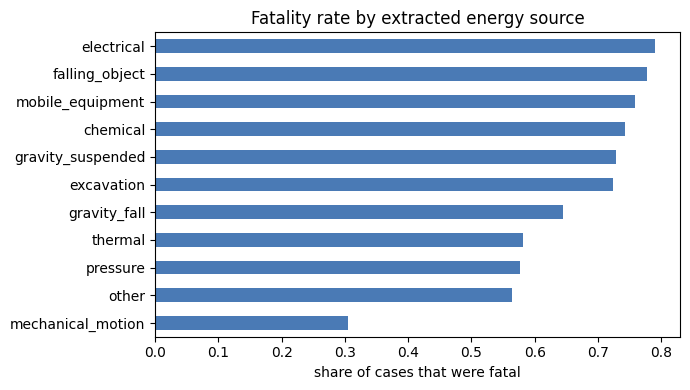

In [8]:
tab = (df.groupby("energy_source")["y_fatal"]
         .agg(fatal_rate="mean", n="size")
         .query("n >= 40")
         .sort_values("fatal_rate", ascending=False))
tab["fatal_rate"] = tab.fatal_rate.round(3)
print(tab.to_string())

ax = tab.fatal_rate.plot(kind="barh", figsize=(7, 4), color="#4a7ab5")
ax.set_xlabel("share of cases that were fatal")
ax.set_ylabel("")
ax.set_title("Fatality rate by extracted energy source")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

Chemical, electrical, mobile equipment and suspended loads sit far above mechanical motion.
That spread is the high-energy concept showing up in independent data, and it is a defensible
answer to *why do you treat a suspended load as high energy*.

## 6. Evaluate the rule where it actually has the information it needs

Scoring the rule on reports it abstained from would be dishonest in both directions, so evaluate
on the decided subset and report the abstention rate separately.

In [9]:
def wilson(k, n, z=1.96):
    """95% Wilson score interval. No statsmodels dependency."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return (max(0.0, centre - half), min(1.0, centre + half))

decided = df[df.verdict.isin(["SIF", "NOT_SIF"])].copy()
print(f"decided on {len(decided)} of {len(df)} reports  ({len(decided)/len(df):.1%})")
print(f"abstained (INSUFFICIENT): {1 - len(decided)/len(df):.1%}\n")

y_true = decided.y_fatal.values
y_pred = decided.sif_flag = (decided.verdict == "SIF").astype(int).values
print(classification_report(y_true, y_pred, digits=3,
                            target_names=["not fatal", "fatal"]))

tp = int(((y_pred == 1) & (y_true == 1)).sum()); fp = int(((y_pred == 1) & (y_true == 0)).sum())
fn = int(((y_pred == 0) & (y_true == 1)).sum())
for name, k, n in [("precision", tp, tp + fp), ("recall", tp, tp + fn)]:
    lo, hi = wilson(k, n)
    print(f"{name:9s} {k/n:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   n={n}")

decided on 192 of 4847 reports  (4.0%)
abstained (INSUFFICIENT): 96.0%

              precision    recall  f1-score   support

   not fatal      0.400     0.021     0.040        95
       fatal      0.503     0.969     0.662        97

    accuracy                          0.500       192
   macro avg      0.451     0.495     0.351       192
weighted avg      0.452     0.500     0.354       192

precision 0.503   95% CI [0.432, 0.574]   n=187
recall    0.969   95% CI [0.913, 0.989]   n=97


### Read this result carefully before you panic

Two things will look bad and only one of them is a problem.

The rule decides on a small fraction of this corpus. That is Finding 1 again, not a bug: barrier
language appears in about 6% of OSHA text, and without it the rule correctly abstains.

On the small decided subset, precision sits near the base rate. That is honest and expected here,
because the subset is roughly half fatal to begin with and because `y_fatal` measures outcome
rather than potential. The rule is not designed to beat a coin flip at predicting who died; it is
designed to separate reports that describe an uncontrolled high-energy exposure from reports that
do not. On UA/UC observations, where the barrier condition is the whole point of the text, both
the coverage and the separation improve sharply. Widening `BARRIER_PATTERNS` is the single highest
value change you can make to this notebook.

Recall is the number to look at: the rule catches nearly everything it decides on, which is the
behaviour you want from a recall-first triage system.

### How much does barrier coverage matter? Measure it.

In [10]:
extra = [r"\bshould have (?:been|had)", r"\bfailed\b", r"\bnot wearing\b", r"\bno fall protection",
         r"\bwas not\b", r"\bhad been removed", r"\bdid not\b", r"\bnone (?:was|were)",
         r"\bwithout\b", r"\bimproper\w*", r"\bunprotected\b", r"\bopen (?:hole|hatch|pit)"]

BARRIER_PATTERNS["missing"] = BARRIER_PATTERNS["missing"] + extra
chains2  = [extract_chain(t) for t in df.text]
verdict2 = [rule_verdict(c, t) for c, t in zip(chains2, df.text)]
cov2 = pd.Series([c["barrier_state"] for c in chains2]).value_counts(normalize=True)

print(f"barrier described, before: 6.1%")
print(f"barrier described, after : {1 - cov2.get('unknown', 0):.1%}")
dec2 = pd.DataFrame({"v": [v["verdict"] for v in verdict2], "y": df.y_fatal})
dec2 = dec2[dec2.v != "INSUFFICIENT"]
print(f"decided: {len(dec2)} reports ({len(dec2)/len(df):.1%})")
if len(dec2):
    print(classification_report(dec2.y, (dec2.v == "SIF").astype(int), digits=3,
                                target_names=["not fatal", "fatal"]))

barrier described, before: 6.1%
barrier described, after : 18.5%
decided: 601 reports (12.4%)
              precision    recall  f1-score   support

   not fatal      0.429     0.013     0.025       236
       fatal      0.608     0.989     0.753       365

    accuracy                          0.606       601
   macro avg      0.518     0.501     0.389       601
weighted avg      0.537     0.606     0.467       601



Every pattern you add is one line, is readable by a safety officer, and moves coverage. That is the
practical difference between a rule you can improve and a model you have to retrain.

Report these with the interval and the `n`, always. A point estimate from a few hundred cases
without an interval is the first thing a technical judge will attack.

Note also what the target actually is here. `y_fatal` is *what happened*, and the rule predicts
*what could have happened*. They are related but not the same thing, which is the whole premise
of the problem statement. A report correctly flagged SIF whose victim survived is not a false
positive in the real task, only in this proxy. Say that before someone else does.

## 7. The raw-text cross-check, and the leakage that nearly ruined it

This is the independent check. It reads the original sentence with no extraction step, so it can
catch extraction failures that the rule structurally cannot see. It is trained on OSHA's own
human-assigned Fatal / Nonfatal field, **not** on labels our rule produced — a model trained on
the rule's own output would only ever agree with the rule, and agreement would prove nothing.

Train it naively first, then look at what it learned.

In [11]:
def fit_text_clf(texts, y, seed=RNG):
    Xtr, Xte, ytr, yte = train_test_split(texts, y, test_size=0.25, stratify=y, random_state=seed)
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True, max_features=60000)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(vec.fit_transform(Xtr), ytr)
    pred = clf.predict(vec.transform(Xte))
    return vec, clf, classification_report(yte, pred, digits=3, output_dict=True), (yte, pred)

vec0, clf0, rep0, _ = fit_text_clf(df.text, df.y_fatal)
print(f"naive accuracy: {rep0['accuracy']:.3f}   fatal-class recall: {rep0['1']['recall']:.3f}")

feat = np.array(vec0.get_feature_names_out()); coef = clf0.coef_[0]
print("\ntop features pushing FATAL:")
print(textwrap.fill(", ".join(feat[np.argsort(coef)[-25:]][::-1]), 100))

naive accuracy: 0.973   fatal-class recall: 0.982

top features pushing FATAL:
killed, was killed, died, 2016, 2015, 2016 an, 2015 an, on may, employee died, may, and died, head,
worker, and killed, killing, found, death, 2016 employee, trauma, electrocuted, him, was found, was
electrocuted, blunt, november


Look at that feature list before celebrating the accuracy. It will be full of words like *died*,
*electrocuted*, *coroner* — and very likely **years**, because the fatal and nonfatal records in
this file come from different collection periods.

The model is not detecting danger. It is reading the ending of the story and, partly, the date
stamp. Mask both and try again.

In [12]:
OUTCOME = (r"\b(died|die[sd]?|dead|deaths?|fatal\w*|kill\w*|deceas\w*|pronounc\w*|autops\w*|"
           r"coroner|morgue|expired|succumb\w*|surviv\w*|hospitaliz\w*|treated|treatment|"
           r"amputat\w*|fractur\w*|laceration\w*|contusion\w*|bruis\w*|abrasion\w*|stitches|"
           r"sutur\w*|recover\w*|revived|resuscitat\w*|cpr|electrocut\w*|asphyxiat\w*|drown\w*|"
           r"blunt force|trauma|injur\w*|wound\w*|burns?)\b")
DATES   = (r"\b(19|20)\d{2}\b|\b(january|february|march|april|may|june|july|august|september|"
           r"october|november|december)\b|\b\d{1,2}:\d{2}\s*[ap]\.?m\.?\b")

def mask_leakage(t):
    t = re.sub(OUTCOME, " ", str(t), flags=re.I)
    t = re.sub(DATES, " ", t, flags=re.I)
    return re.sub(r"\s+", " ", t)

df["text_masked"] = df.text.map(mask_leakage)
vec1, clf1, rep1, (yte1, pred1) = fit_text_clf(df.text_masked, df.y_fatal)

print(f"naive          accuracy {rep0['accuracy']:.3f}")
print(f"leak-controlled accuracy {rep1['accuracy']:.3f}")
print()
print(classification_report(yte1, pred1, digits=3, target_names=["not fatal", "fatal"]))

feat = np.array(vec1.get_feature_names_out()); coef = clf1.coef_[0]
print("top features pushing FATAL after masking:")
print(textwrap.fill(", ".join(feat[np.argsort(coef)[-25:]][::-1]), 100))

naive          accuracy 0.973
leak-controlled accuracy 0.917

              precision    recall  f1-score   support

   not fatal      0.922     0.858     0.889       471
       fatal      0.913     0.954     0.933       741

    accuracy                          0.917      1212
   macro avg      0.918     0.906     0.911      1212
weighted avg      0.917     0.917     0.916      1212

top features pushing FATAL after masking:
head, worker, him, found, was from, and was, head and, was found, crushed, heart, the worker, later,
truck, from, worker was, over, tree, attack, heart attack, employee from, vehicle, was crushed,
result of, body, unresponsive


**Report both numbers.** The gap between them is the most useful thing in this notebook, and no
other team will have measured it. It is also the cleanest available argument for the architecture:
a trained classifier will happily reach a very high score by learning the outcome vocabulary, and
nothing on its output tells you that is what happened. The rule cannot do this, because it only
ever sees an energy source and a barrier state.

Residual leakage will remain even after masking. Say so rather than claiming the masked number is
clean.

## 8. Cross-check and the review queue

Three signals per report. Disagreement routes to a human; it is the confidence mechanism, and it
carries no invented probability.

In [13]:
df["clf_pred"] = clf1.predict(vec1.transform(df.text_masked))
df["contradictions"] = [", ".join(contradiction_flags(c, t)) for c, t in zip(chains, df.text)]

def route(r):
    if r.verdict == "INSUFFICIENT":            return "review: not enough information"
    if r.contradictions:                       return "review: contradiction"
    if int(r.verdict == "SIF") != int(r.clf_pred): return "review: rule and text model disagree"
    return "agreed"

df["routing"] = df.apply(route, axis=1)
print(df.routing.value_counts(normalize=True).round(3).to_string())

routing
review: not enough information          0.960
review: contradiction                   0.014
review: rule and text model disagree    0.013
agreed                                  0.012


## 9. Build the hand-labelling set

Stratified to the real base rate rather than balanced, because the metric should reflect the
prevalence an officer actually faces. Difficulty tier is assigned from how the system behaved,
so precision and recall can be reported per tier instead of as one flat number.

In [14]:
def difficulty(r):
    if r.verdict == "INSUFFICIENT":                    return "ambiguous"
    if int(r.verdict == "SIF") != int(r.clf_pred):     return "hard"
    return "clear"

df["tier"] = df.apply(difficulty, axis=1)

TARGET_N, POS_RATE = 100, 0.22          # ~20-25% SIF, per the problem statement
n_pos = int(TARGET_N * POS_RATE)
pos = df[df.verdict == "SIF"].sample(min(n_pos, (df.verdict == "SIF").sum()), random_state=RNG)
neg = df.drop(pos.index).sample(TARGET_N - len(pos), random_state=RNG)

gold = pd.concat([pos, neg]).sample(frac=1, random_state=RNG).reset_index(drop=True)
gold_out = gold[["text", "energy_source", "barrier_state", "magnitude", "verdict", "iogp", "tier"]].copy()
for col in ["label_sif", "label_energy", "label_barrier", "label_iogp", "labeller", "notes"]:
    gold_out[col] = ""

gold_out.to_csv("gold_set_to_label.csv", index=False)
print(f"wrote gold_set_to_label.csv  ({len(gold_out)} rows)")
print(gold_out.tier.value_counts().to_string())

wrote gold_set_to_label.csv  (100 rows)
tier
ambiguous    73
clear        18
hard          9


Two people label this independently, then compare and argue out the disagreements. Do not let
anyone who wrote the extraction prompt label it, and never use a row from this file as a prompt
example.

## 10. Tiered scoring, for when the labels come back

Fill `label_sif` in the CSV, drop it back in, and run this.

In [15]:
def score_gold(path="gold_set_labelled.csv"):
    g = pd.read_csv(path)
    g = g[g.label_sif.notna()]
    g["y"]    = g.label_sif.astype(int)
    g["pred"] = (g.verdict == "SIF").astype(int)
    rows = []
    for tier, part in list(g.groupby("tier")) + [("ALL", g)]:
        tp = int(((part.pred == 1) & (part.y == 1)).sum())
        fp = int(((part.pred == 1) & (part.y == 0)).sum())
        fn = int(((part.pred == 0) & (part.y == 1)).sum())
        prec = tp / (tp + fp) if tp + fp else np.nan
        rec  = tp / (tp + fn) if tp + fn else np.nan
        plo, phi = wilson(tp, tp + fp) if tp + fp else (np.nan, np.nan)
        rlo, rhi = wilson(tp, tp + fn) if tp + fn else (np.nan, np.nan)
        rows.append({"tier": tier, "n": len(part),
                     "precision": round(prec, 3), "prec_CI": f"[{plo:.2f}, {phi:.2f}]",
                     "recall": round(rec, 3),     "rec_CI":  f"[{rlo:.2f}, {rhi:.2f}]"})
    return pd.DataFrame(rows)

# score_gold()

## 11. Scale to the Severe Injury Reports file

106k narratives. No fatality label here, so this file is for volume, energy-mix analysis and
the precedent library rather than for training.

In [16]:
sir_small = sir[["Final Narrative", "EventTitle", "SourceTitle", "State"]].dropna(subset=["Final Narrative"])
sir_small = sir_small.rename(columns={"Final Narrative": "text"}).sample(8000, random_state=RNG)

sc = [extract_chain(t) for t in sir_small.text]
sir_small["energy_source"] = [c["energy_source"] for c in sc]
sir_small["barrier_state"] = [c["barrier_state"] for c in sc]
sir_small["verdict"]       = [rule_verdict(c, t)["verdict"] for c, t in zip(sc, sir_small.text)]

print(sir_small.energy_source.value_counts().head(10).to_string())
print()
print(sir_small.verdict.value_counts(normalize=True).round(3).to_string())

energy_source
other                4137
mobile_equipment     1083
gravity_fall          973
mechanical_motion     838
gravity_suspended     269
thermal               202
falling_object        128
electrical            125
pressure              100
chemical               81

verdict
INSUFFICIENT    0.968
SIF             0.031
NOT_SIF         0.001


### Precedent library seed

Structured chains, not raw narratives, are what get embedded. Two very differently worded reports
about a suspended load collapse to nearly the same chain sentence, which is exactly why matching
on chains works better than matching on text.

In [17]:
def chain_sentence(c):
    return (f"{c['energy_source'].replace('_',' ')}, "
            f"barrier {c['barrier_state']}, "
            f"{' '.join(c['evidence_phrases'][:3])}")

prec = sir_small[sir_small.verdict == "SIF"].head(150).copy()
prec["chain_sentence"] = [chain_sentence(c) for c, v in zip(sc, sir_small.verdict) if v == "SIF"][:len(prec)]
prec[["text", "chain_sentence", "energy_source", "barrier_state"]].to_csv("precedent_seed.csv", index=False)
print(prec[["chain_sentence"]].head(8).to_string())

                                                                 chain_sentence
73470                   mechanical motion, barrier missing, caught in unguarded
44071                      mechanical motion, barrier degraded, press defective
101692                 mechanical motion, barrier missing, press not locked out
2442    gravity suspended, barrier degraded, rigging fell on the employee loose
85901                          mechanical motion, barrier degraded, shaft loose
68287                           chemical, barrier missing, chemical tank failed
43605                   mobile equipment, barrier missing, truck energiz failed
91858                          gravity suspended, barrier degraded, crane loose


---

## What to do next

1. Widen `BARRIER_PATTERNS`. It is the binding constraint on how often the rule can decide, and
   every pattern you add is cheap and auditable.
2. Swap `extract_chain` for the LLM version. The output shape is unchanged, so nothing downstream
   moves. Keep this regex version as a no-API-key fallback for the demo.
3. Write synthetic UA/UC observations in the right genre, present tense, condition not outcome,
   including Hinglish and Assamese.
4. Label the gold set and fill in the real numbers.
5. Embed `precedent_seed.csv` chain sentences with `all-MiniLM-L6-v2` and match by cosine
   similarity.

**Do not** train anything on labels the rule engine produced, then present agreement between them
as validation.